### 공통 setting

In [1]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

In [2]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520,520)),
    T.ToTensor()
])

In [4]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

In [18]:
colormap = np.zeros((256,3), dtype=int)
ind = np.arange(256, dtype=int)

In [19]:
for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3  

### 1. 아웃포커싱(인물 사진)

In [5]:
human_img_path = "./data/mk.jpg"

In [6]:
human_img_org = cv2.imread(human_img_path)
print(f"인물 사진 크기: {human_img_org.shape}")

인물 사진 크기: (4032, 3024, 3)


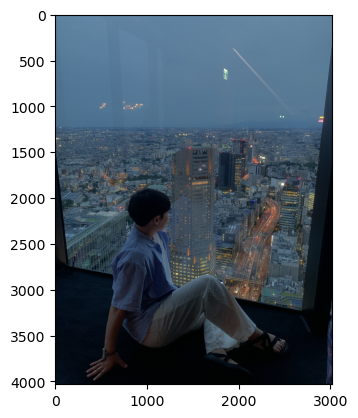

In [7]:
plt.imshow(cv2.cvtColor(human_img_org, cv2.COLOR_BGR2RGB))
plt.show()

In [8]:
human_input_tensor = transform(cv2.cvtColor(human_img_org, cv2.COLOR_BGR2RGB)).unsqueeze(0)
print(human_input_tensor.shape)

torch.Size([1, 3, 520, 520])


In [9]:
%time
with torch.no_grad():
    # human_output_tensor: (21, 520, 520) -> 채널 축(21): 모델이 예측한 class
    human_output_tensor = model(human_input_tensor)['out'][0]
    # 채널 방향에서 최댓값의 idx -> 최댓값의 class
    human_output_pred = human_output_tensor.argmax(0).byte().cpu().numpy() 

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 6.2 μs


In [10]:
print(human_img_org.shape)

(4032, 3024, 3)


In [11]:
# mask 결과 보기 위해 원본 이미지 크기로 복원
human_output_pred_resized = cv2.resize(human_output_pred, 
                                       (human_img_org.shape[1], human_img_org.shape[0]), 
                                       interpolation = cv2.INTER_NEAREST)

In [13]:
print(human_output_pred_resized.shape) # 원본 이미지 크기 됨

(4032, 3024)


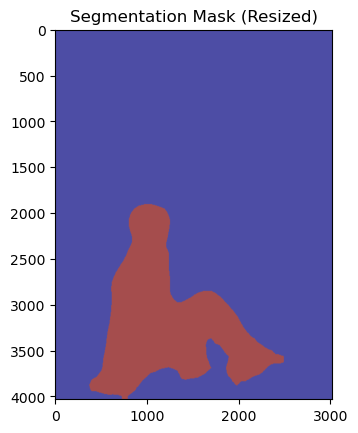

In [15]:
plt.imshow(human_output_pred_resized, cmap='jet', alpha=0.7)
plt.title('Segmentation Mask (Resized)')
plt.show()

In [16]:
human_unique_classes = np.unique(human_output_pred_resized)
print(human_unique_classes)

[ 0 15]


In [17]:
for class_id in human_unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [20]:
colormap[15]

array([192, 128, 128])

In [22]:
human_seg_map = (human_output_pred_resized == 15) # 사람에 해당하는 영역 1로
human_img_mask = human_seg_map.astype(np.uint8)*255 # 사람에 해당하는 영역만 255로
human_color_mask = cv2.applyColorMap(human_img_mask, cv2.COLORMAP_JET)

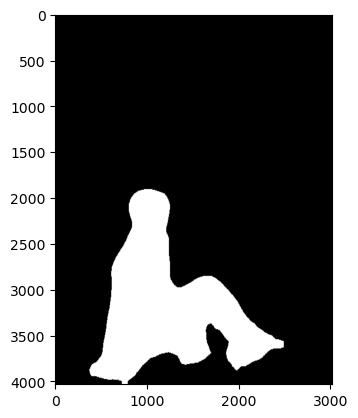

In [23]:
plt.imshow(human_img_mask, cmap='gray')
plt.show()

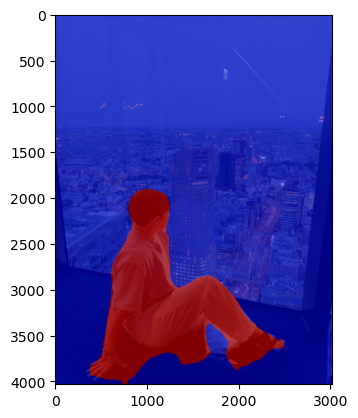

In [24]:
human_img_show = cv2.addWeighted(human_img_org, 0.5, human_color_mask, 1.0, 0.0)
plt.imshow(cv2.cvtColor(human_img_show, cv2.COLOR_BGR2RGB))
plt.show()

In [25]:
# 문제점 분석 위해 저장
cv2.imwrite("human_img_show.jpg", human_img_show)

True

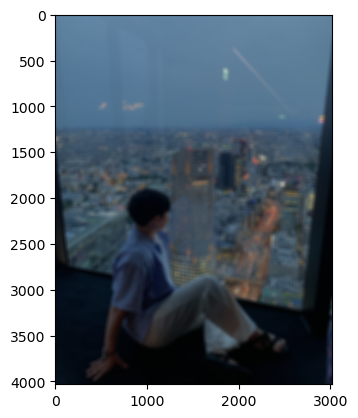

In [26]:
human_img_org_blur = cv2.blur(human_img_org, (50, 50)) # 원본 이미지 블러 처리
plt.imshow(cv2.cvtColor(human_img_org_blur, cv2.COLOR_BGR2RGB))
plt.show()

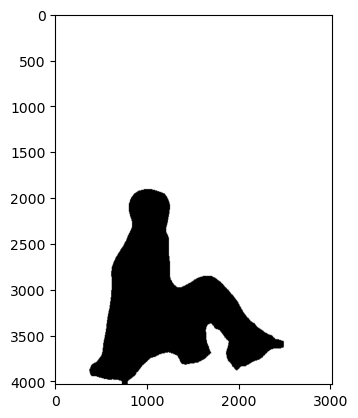

In [27]:
human_img_mask_color = cv2.cvtColor(human_img_mask, cv2.COLOR_BGR2RGB) # 객체 255값
human_img_bg_mask = cv2.bitwise_not(human_img_mask_color) # 배경 255값 -> 흰색

# plt.imshow(cv2.cvtColor(img_mask_color, cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(human_img_bg_mask, cv2.COLOR_BGR2RGB))
plt.show()

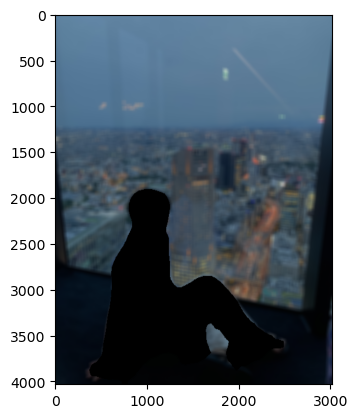

In [28]:
# 객체 0, 배경 255니까 배경만 살리기
human_img_bg_blur = cv2.bitwise_and(human_img_org_blur, human_img_bg_mask) 
plt.imshow(cv2.cvtColor(human_img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

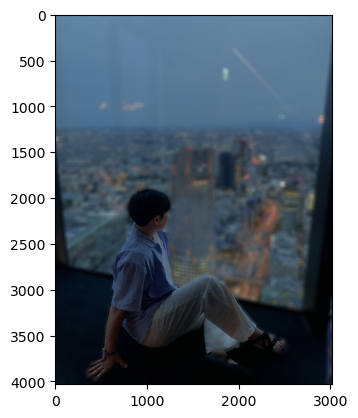

In [29]:
# human_img_mask_color: 객체만 255값
human_img_concat = np.where(human_img_mask_color == 255, human_img_org, human_img_bg_blur)
plt.imshow(cv2.cvtColor(human_img_concat, cv2.COLOR_BGR2RGB))
plt.show()

In [30]:
# 문제점 분석 위해 저장
cv2.imwrite('human_seg_result.jpg', human_img_concat)

True

### 문제점 분석

In [31]:
issue_img_path = "issue_capture.png"

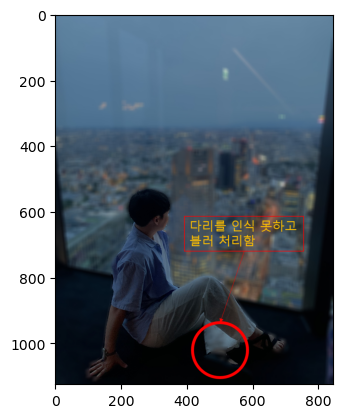

In [32]:
issue_img = cv2.imread(issue_img_path)
plt.imshow(cv2.cvtColor(issue_img, cv2.COLOR_BGR2RGB))
plt.show()

In [33]:
res_mask_path = "human_img_show.jpg"

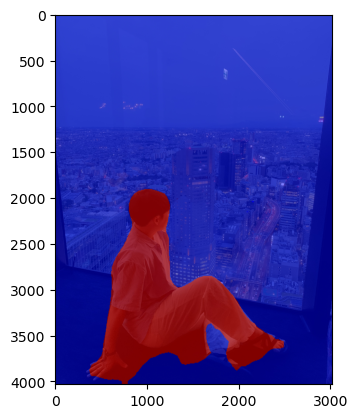

In [34]:
res_mask = cv2.imread(res_mask_path)
plt.imshow(cv2.cvtColor(res_mask, cv2.COLOR_BGR2RGB))
plt.show()

- 문제점
    - 모델이 바닥면에 닿은 신체의 edge를 구분하지 못함 (신체와 바닥을 덩어리로 뭉뚱그려서 인식함)

![deeplab_V3_archtecture](https://bloglunit.wordpress.com/wp-content/uploads/2018/07/deeplabv3.png)

![Atrous Convolution filter](https://bloglunit.wordpress.com/wp-content/uploads/2018/07/atrous.png)

- 원인 추정
    - deeplab V3의 구조를 보면 convolution 연산으로 특징을 추출하고, upsampling을 할 때, Bilinear upsampling만 적용해서 한 번에 이미지 사이즈를 8배 확대하는 것을 볼 수 있음 -> 바닥면에서 edge정보를 포착했다해도 upsampling 과정에서 유실됐을 것으로 보임
    - Atrous Convolution 과정에서 필터 내부에 공간을 많이 둬서, 포착하려는 픽셀 사이 간격이 너무 넓어서 손과 바닥을 동일한 개체로 뭉뚱그려서 포착했을 수 있음

- 해결 방안
    - upsampling을 할 때 **한 번에 이미지 사이즈를 키우지 말고**, convolution layer를 거치면서 포착한 **저수준의 위치 정보를 scale 별로 fusion하면서 upsampling**을 수행하면(deeplabV3+에서는 4배 확대하고, 저수준의 정보를 concat한 뒤 다시 4배 확대함), 국소적인 영역에서 포착한 edge 같은 정보를 반영하여 좀더 세밀한 구분이 가능할 것으로 보임
    - Atrous Convolution 과정에서 **필터 내부에 빈 공간을 줄여서 이전보다 촘촘하게 패턴을 파악하도록 수정**하면, 바닥과 신체를 덩어리로 보지 않고 좀더 명확하게 구분할 수 있을 것으로 보임

### 2. 아웃포커싱(동물사진)

In [35]:
dog_img_path = "./data/dogs.jpg"

In [36]:
dog_img_org = cv2.imread(dog_img_path)
print(f"이미지 크기: {dog_img_org.shape}")

이미지 크기: (4032, 3024, 3)


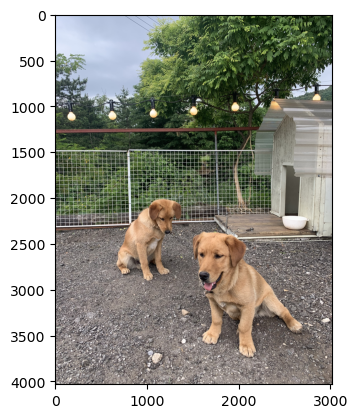

In [37]:
plt.imshow(cv2.cvtColor(dog_img_org, cv2.COLOR_BGR2RGB))
plt.show()

In [38]:
dog_input_tensor = transform(cv2.cvtColor(dog_img_org, cv2.COLOR_BGR2RGB)).unsqueeze(0)
print(dog_input_tensor.shape)

torch.Size([1, 3, 520, 520])


In [39]:
%time
with torch.no_grad():
    # (21, 520, 520) -> 채널: class
    dog_output_tensor = model(dog_input_tensor)['out'][0] 
    # 채널 방향에서 최댓값의 idx -> 최댓값의 class
    dog_output_pred = dog_output_tensor.argmax(0).byte().cpu().numpy()

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 5.48 μs


In [40]:
dog_output_pred_resized = cv2.resize(dog_output_pred, 
                                     (dog_img_org.shape[1], dog_img_org.shape[0]),
                                     interpolation = cv2.INTER_NEAREST)
print(dog_output_pred_resized.shape)

(4032, 3024)


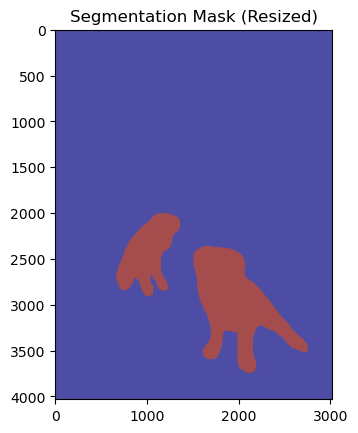

In [41]:
plt.imshow(dog_output_pred_resized, cmap='jet', alpha=0.7)
plt.title('Segmentation Mask (Resized)')
plt.show()

In [42]:
dog_unique_classes = np.unique(dog_output_pred_resized)
print(dog_unique_classes)

[ 0 12]


In [43]:
for class_id in dog_unique_classes:
    print(LABEL_NAMES[class_id])

background
dog


In [44]:
colormap[12]

array([ 64,   0, 128])

In [45]:
dog_seg_map = (dog_output_pred_resized == 12) # 개에 해당하는 영역 1로
dog_img_mask = dog_seg_map.astype(np.uint8)*255 # 개에 해당하는 영역만 255로
dog_color_mask = cv2.applyColorMap(dog_img_mask, cv2.COLORMAP_JET)

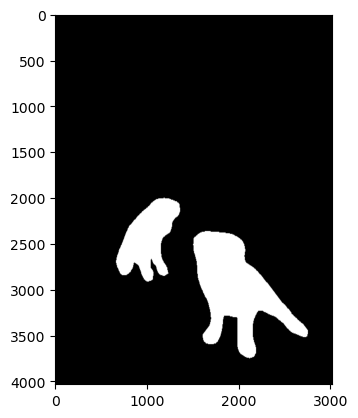

In [46]:
plt.imshow(dog_img_mask, cmap='gray')
plt.show()

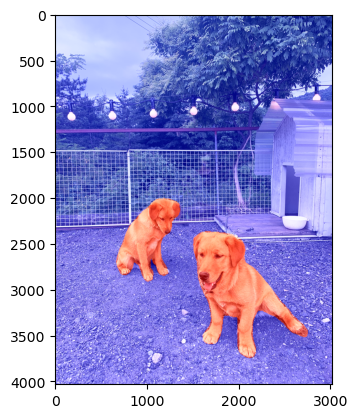

In [47]:
dog_img_show = cv2.addWeighted(dog_img_org, 1.0, dog_color_mask, 1.0, 0.0)
plt.imshow(cv2.cvtColor(dog_img_show, cv2.COLOR_BGR2RGB))
plt.show()

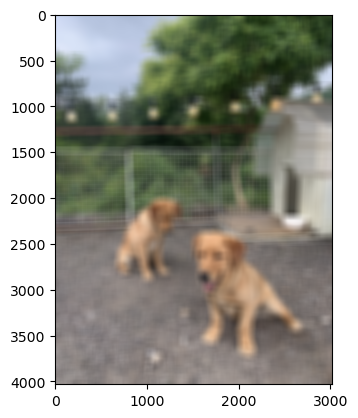

In [48]:
dog_img_org_blur = cv2.blur(dog_img_org, (100, 100))
plt.imshow(cv2.cvtColor(dog_img_org_blur, cv2.COLOR_BGR2RGB))
plt.show()

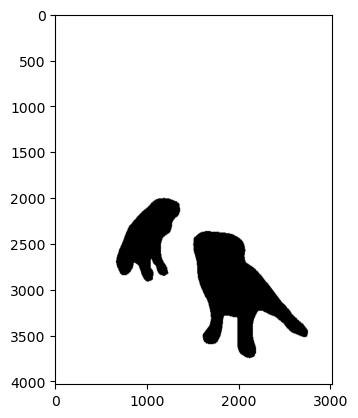

In [49]:
dog_img_mask_color = cv2.cvtColor(dog_img_mask, cv2.COLOR_BGR2RGB) # 객체 255값
dog_img_bg_mask = cv2.bitwise_not(dog_img_mask_color) # 배경 255값 -> 흰색

# plt.imshow(cv2.cvtColor(dog_img_mask_color, cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(dog_img_bg_mask, cv2.COLOR_BGR2RGB))
plt.show()

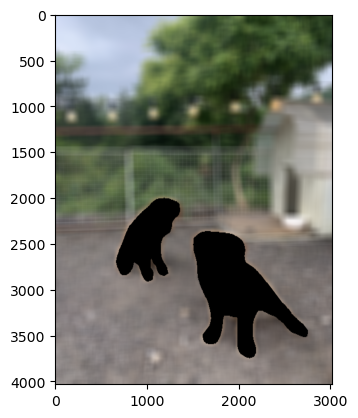

In [50]:
# 객체 0, 배경 255니까 배경만 살리기
dog_img_bg_blur = cv2.bitwise_and(dog_img_org_blur, dog_img_bg_mask) 
plt.imshow(cv2.cvtColor(dog_img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

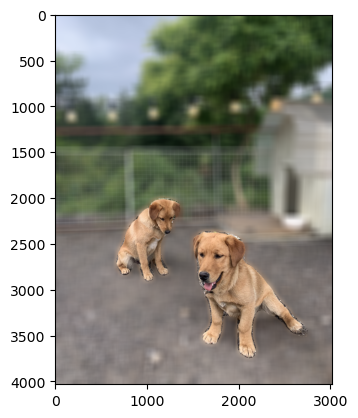

In [51]:
# img_mask_color: 객체만 255값
dog_img_concat = np.where(dog_img_mask_color == 255, dog_img_org, dog_img_bg_blur)
plt.imshow(cv2.cvtColor(dog_img_concat, cv2.COLOR_BGR2RGB))
plt.show()

### 3. 배경 크로마키

In [52]:
obj_img_path = "./data/dogs.jpg"
bg_img_path = "./data/beach.jpg"

In [53]:
obj_img = cv2.imread(obj_img_path)
bg_img = cv2.imread(bg_img_path)

obj_img = cv2.cvtColor(obj_img, cv2.COLOR_BGR2RGB)
bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)

In [54]:
print(f"객체 이미지 크기: {obj_img.shape}")
print(f"배경 이미지 크기: {bg_img.shape}")

객체 이미지 크기: (4032, 3024, 3)
배경 이미지 크기: (1066, 1600, 3)


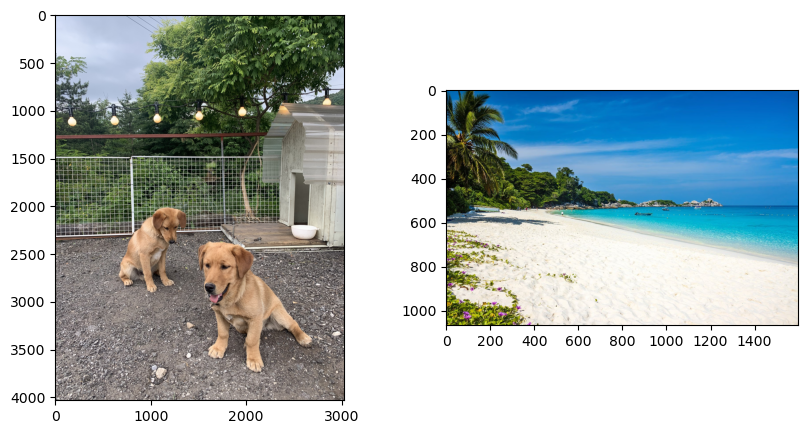

In [55]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(obj_img)

plt.subplot(1, 2, 2)
plt.imshow(bg_img)

plt.show()

In [56]:
input_tensor = transform(obj_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

In [57]:
# 개체 사진에 대해 모델이 예측한 output의 shape
print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [58]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, 
                                        (obj_img.shape[1], obj_img.shape[0]), 
                                        interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (4032, 3024)


In [59]:
obj_unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {obj_unique_classes}")

예측된 클래스 ID: [ 0 12]


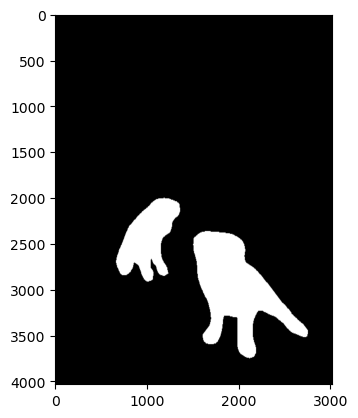

In [60]:
target_class_id = obj_unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

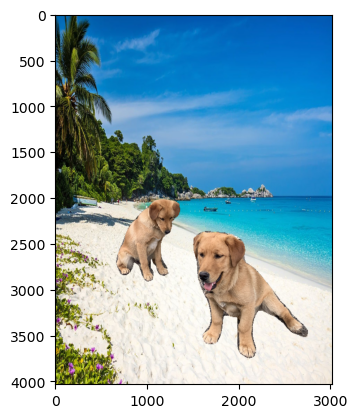

In [61]:
# 배경을 개체가 있는 이미지 크기에 맞춤
bg_img_resized = cv2.resize(bg_img, (obj_img.shape[1], obj_img.shape[0]))

# 개체 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
result_img = np.where(img_mask_color == 255, obj_img, bg_img_resized)

plt.imshow(result_img)
plt.show()